### VISUALIZING AND UNDERSTANDING THE MNIST DATASET

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

"""
In these lines of code, we are downloading the MNIST dataset from the sklearn library.
We can import the datasets in 3 different formats:
1. fetch_*: Download it from the internet, The by default are made in the pandas Dataframe format. 
2. make_*: Generate the fake dataset randomly.
3. load_*: Load one of small datasets that are pre-downloaded along with the sklearn library itself.

Now, the dataset that we will be downloading is named as 'mnist_784'. We wrote as_frame = False as MNIST dataset is bunch of images, which is not suitable for the dataframe format.
"""

In [ ]:
x, y = mnist.data, mnist.target
print(x, y)
print(x.shape) # x is a 2D matrix that has 70000 images, and dimension of each image is 28x28, which when flattened out, gives us the 1D array of size 784
print(y.shape) # y is an 1D array that simply contains the TRUE labels of each corresponding image, like the 1st image in MNIST dataset is 5, 2nd is 0, 3rd is 4, etc.

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] ['5' '0' '4' ... '4' '5' '6']
(70000, 784)
(70000,)


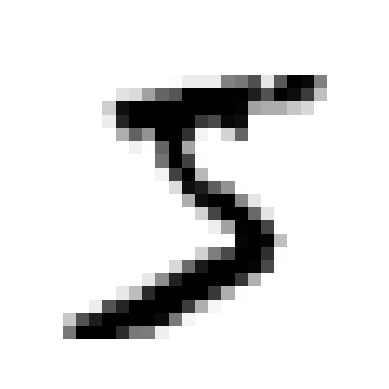

'5'

In [8]:
import matplotlib.pyplot as plt

some_image = x[0] #Loaded a random images from x, say x[0]

def plot_image(some_image):
    image = some_image.reshape(28,28) #Reshaped a 784 array back to its original 2D format.
    plt.imshow(image, cmap="binary") #To create the image in the binary format ie.- black and white
    plt.axis("off")

plot_image(some_image)
plt.show()

y[0]

### Spliting the data into train and test set AND training a classifier

In [ ]:
#The scikit dataset for MNIST is already split into training and the testing part where first 60000 images are for training purposes but the remaining ones for testing
x_train, y_train, x_test, y_test = x[:60000], y[:60000], x[60000:], y[60000:]

y_train_5 = (y_train == '5') #Just a true/false mask. Mask can be of different types: we can also write something like: y_train_5 = ['5' if y == '5' else 'no_5' for y in y_train]
y_test_5 = (y_test == '5')

In [ ]:
"""
OR if we need to split the training and testing data from sklearn, use:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)

stratify = y just to ensure that we follow stratified sampling during train and test sets creation.
"""

In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_5) #It is learning: What kind of image patterns lead to True vs False where x_train has raw and unlabelled images, and y_train_5 has true labels wither Truth or Fallacy

sgd_clf.predict([some_image])
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_5, cv =5, scoring='accuracy')

array([0.95466667, 0.96975   , 0.9635    , 0.96533333, 0.94841667])

In [20]:
dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)

cross_val_score(dummy_clf, x_train, y_train_5, cv =5, scoring='accuracy')

array([0.90958333, 0.90966667, 0.90966667, 0.90966667, 0.90966667])

### Implementing our own cross-validation sets from scratch